## Ejercicio 1

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss

df = pd.read_csv("../data/raw/guatemala_temperatura.csv", parse_dates=["month"])
df.head()

,month,year,month_num,dewpoint_2m_c,temperature_2m_c,skin_temperature_c,soil_temperature_layer_1_c,soil_temperature_layer_2_c,soil_temperature_layer_3_c,soil_temperature_layer_4_c
0,1950-01-01,1950,1,16.685643,20.762313,21.077662,21.661654,21.679957,21.835225,22.458468
1,1950-02-01,1950,2,15.781276,21.051057,21.518684,22.132758,22.062957,21.964048,22.216061
2,1950-03-01,1950,3,17.330139,23.197594,23.838886,24.374884,24.100146,23.304599,22.380270
3,1950-04-01,1950,4,16.499826,23.661600,24.452373,25.059722,24.752231,24.059086,22.955561
4,1950-05-01,1950,5,19.011177,24.804521,25.501737,26.154377,25.941164,25.252762,23.687375


In [6]:
df.describe()

,month,year,month_num,dewpoint_2m_c,temperature_2m_c,skin_temperature_c,soil_temperature_layer_1_c,soil_temperature_layer_2_c,soil_temperature_layer_3_c,soil_temperature_layer_4_c
count,918,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,1988-03-16 18:29:01.176470,1987.751634,6.480392,18.736168,23.050184,23.443820,24.096186,24.066521,24.010561,23.960867
min,1950-01-01 00:00:00,1950.000000,1.000000,14.198656,18.970146,19.145766,19.837591,19.960146,20.486906,21.566859
25%,1969-02-08 00:00:00,1969.000000,3.000000,17.159645,21.815698,22.066246,22.716301,22.799033,22.936150,23.174425
50%,1988-03-16 12:00:00,1988.000000,6.000000,19.078054,23.256937,23.643262,24.315492,24.274114,24.213858,24.070931
75%,2007-04-23 12:00:00,2007.000000,9.000000,20.337119,24.137825,24.574924,25.215864,25.169290,24.967106,24.638497
max,2026-06-01 00:00:00,2026.000000,12.000000,21.959664,28.686405,29.736339,30.293318,29.804204,28.346901,26.876606
std,NaN,22.096630,3.453879,1.826790,1.568933,1.716298,1.710498,1.599642,1.313116,0.965742


In [7]:
capas = [
    "temperature_2m_c",
    "soil_temperature_layer_1_c",
    "soil_temperature_layer_2_c",
    "soil_temperature_layer_3_c",
    "soil_temperature_layer_4_c",
]

for c_ in capas:
    fmax = df.loc[df[c_].idxmax()]
    fmin = df.loc[df[c_].idxmin()]
    print(f"{c_}: max={fmax[c_]:.2f} ({fmax['month'].date()})  min={fmin[c_]:.2f} ({fmin['month'].date()})")

temperature_2m_c: max=28.69 (2024-05-01)  min=18.97 (1956-01-01)
soil_temperature_layer_1_c: max=30.29 (2024-05-01)  min=19.84 (1956-01-01)
soil_temperature_layer_2_c: max=29.80 (2024-05-01)  min=19.96 (1956-01-01)
soil_temperature_layer_3_c: max=28.35 (2024-05-01)  min=20.49 (1956-01-01)
soil_temperature_layer_4_c: max=26.88 (2024-06-01)  min=21.57 (1976-02-01)


In [8]:
df["t"] = (df["year"] - df["year"].min()) + (df["month_num"] - 1) / 12

for c_ in capas:
    slope, intercept, r, p, se = stats.linregress(df["t"], df[c_])
    print(f"{c_}: {slope:.4f} C/año  (p={p:.4g})")

temperature_2m_c: 0.0171 C/año  (p=1.491e-13)
soil_temperature_layer_1_c: 0.0168 C/año  (p=2.936e-11)
soil_temperature_layer_2_c: 0.0167 C/año  (p=1.301e-12)
soil_temperature_layer_3_c: 0.0166 C/año  (p=6.061e-18)
soil_temperature_layer_4_c: 0.0165 C/año  (p=1.866e-32)


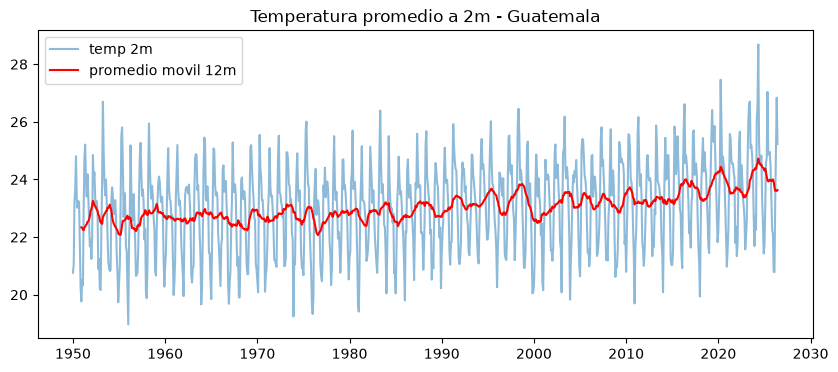

In [9]:
df["temp_2m_rolling"] = df["temperature_2m_c"].rolling(12).mean()
plt.figure(figsize=(10, 4))
plt.plot(df["month"], df["temperature_2m_c"], alpha=0.5, label="temp 2m")
plt.plot(df["month"], df["temp_2m_rolling"], color="red", label="promedio movil 12m")
plt.legend()
plt.title("Temperatura promedio a 2m - Guatemala")
plt.show()

## Ejercicio 2

In [10]:
# la limpieza y el split estan en src/preparar_datos.py
%run ../src/preparar_datos.py

train = pd.read_csv("../data/processed/train.csv", parse_dates=["month"])
test = pd.read_csv("../data/processed/test.csv", parse_dates=["month"])
print("train:", train["month"].min().date(), "-", train["month"].max().date())
print("test: ", test["month"].min().date(), "-", test["month"].max().date())

train: (882, 10)  test: (36, 10)
train: 1950-01-01 - 2023-06-01
test:  2023-07-01 - 2026-06-01


## Ejercicio 3

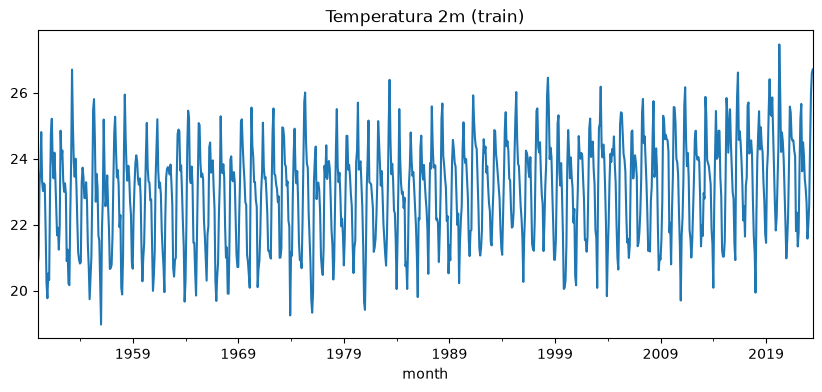

In [7]:
ts = train.set_index("month")["temperature_2m_c"]
ts.index.freq = "MS"
ts.plot(figsize=(10, 4), title="Temperatura 2m (train)")
plt.show()

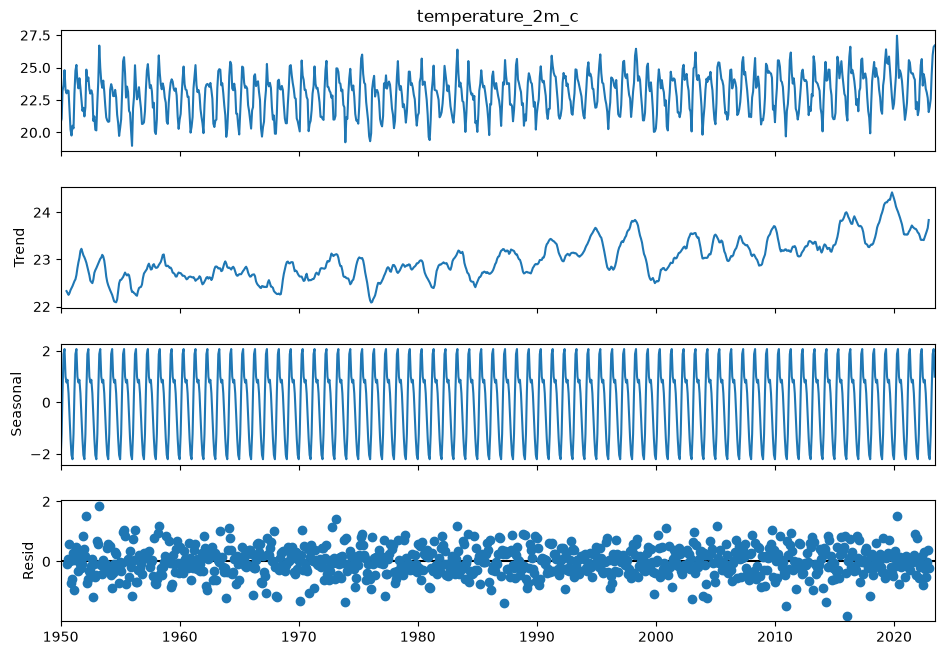

In [8]:
# a) descomposicion
decomp = seasonal_decompose(ts, model="additive", period=12)
decomp.plot()
plt.gcf().set_size_inches(10, 7)
plt.show()

In [9]:
# b) tendencia
t = range(len(ts))
slope, intercept, r, p, se = stats.linregress(t, ts.values)
print(f"pendiente: {slope:.4f} C/mes, p-value: {p:.4g}")

pendiente: 0.0013 C/mes, p-value: 7.219e-11


In [10]:
# c) estacionariedad en media
adf_stat, adf_p, *_ = adfuller(ts)
print("ADF p-value:", adf_p)

kpss_stat, kpss_p, *_ = kpss(ts, regression="c", nlags="auto")
print("KPSS p-value:", kpss_p)

ADF p-value: 0.00035337048894957136
KPSS p-value: 0.01


/tmp/ipykernel_143561/4077656035.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(ts, regression="c", nlags="auto")


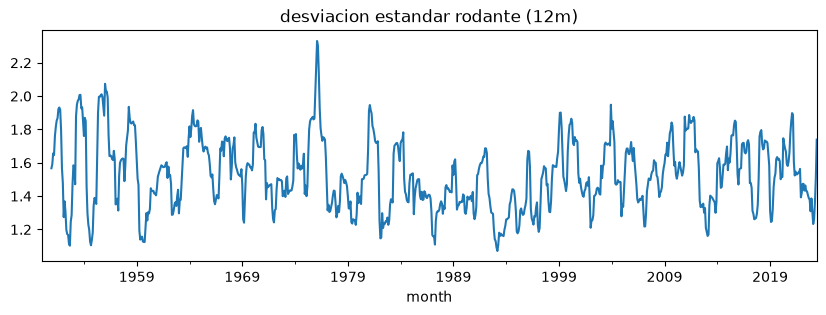

var primera mitad: 2.3194500150420665
var segunda mitad: 2.270570701768244


In [11]:
# estacionariedad en varianza
ts.rolling(12).std().plot(figsize=(10, 3), title="desviacion estandar rodante (12m)")
plt.show()

mitad = len(ts) // 2
print("var primera mitad:", ts.iloc[:mitad].var())
print("var segunda mitad:", ts.iloc[mitad:].var())

## Ejercicio 4

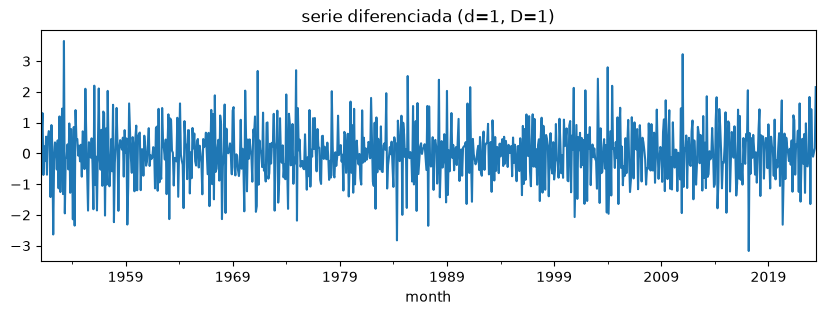

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# la varianza ya era estable, solo hay que diferenciar para quitar tendencia y estacionalidad
ts_diff = ts.diff().diff(12).dropna()
ts_diff.plot(figsize=(10, 3), title="serie diferenciada (d=1, D=1)")
plt.show()

In [13]:
# verificar que ya es estacionaria en media
adf_stat, adf_p, *_ = adfuller(ts_diff)
print("ADF p-value:", adf_p)

kpss_stat, kpss_p, *_ = kpss(ts_diff, regression="c", nlags="auto")
print("KPSS p-value:", kpss_p)

ADF p-value: 9.050655854766046e-26
KPSS p-value: 0.1


/tmp/ipykernel_143561/2760701597.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(ts_diff, regression="c", nlags="auto")


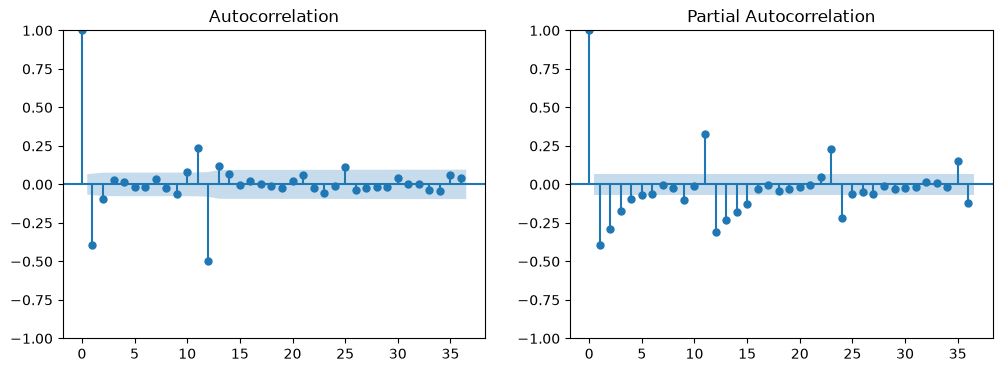

In [14]:
# ACF y PACF para estimar p y q
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ts_diff, lags=36, ax=axes[0])
plot_pacf(ts_diff, lags=36, ax=axes[1])
plt.show()

In [15]:
# modelo 1: SARIMA(1,1,1)(1,1,1,12) segun lo que se ve en ACF/PACF
modelo1 = SARIMAX(ts, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
print(modelo1.summary().tables[0])
print("AIC:", modelo1.aic)

                                     SARIMAX Results                                      
Dep. Variable:                   temperature_2m_c   No. Observations:                  882
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -727.988
Date:                            Thu, 16 Jul 2026   AIC                           1465.976
Time:                                    18:30:56   BIC                           1489.813
Sample:                                01-01-1950   HQIC                          1475.097
                                     - 06-01-2023                                         
Covariance Type:                              opg                                         
AIC: 1465.9762167989577


In [16]:
# modelo 2: mas rezagos AR
modelo2 = SARIMAX(ts, order=(2, 1, 2), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
print("AIC:", modelo2.aic)

/home/DiegoPatzan/Documents/UVG/DATA/EJERCICIO1/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AIC: 1445.4494422145588


In [17]:
# modelo 3: sin diferenciacion regular, solo la estacional
modelo3 = SARIMAX(ts, order=(1, 0, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
print("AIC:", modelo3.aic)

AIC: 1451.5776794147373


In [18]:
print("modelo1 SARIMA(1,1,1)(1,1,1,12) AIC:", round(modelo1.aic, 2))
print("modelo2 SARIMA(2,1,2)(1,1,1,12) AIC:", round(modelo2.aic, 2))
print("modelo3 SARIMA(1,0,1)(0,1,1,12) AIC:", round(modelo3.aic, 2))

modelo1 SARIMA(1,1,1)(1,1,1,12) AIC: 1465.98
modelo2 SARIMA(2,1,2)(1,1,1,12) AIC: 1445.45
modelo3 SARIMA(1,0,1)(0,1,1,12) AIC: 1451.58


## Ejercicio 5

In [19]:
# a) significacion de los coeficientes (valido el modelo2, el de mejor AIC)
print(modelo2.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8030      0.153      5.247      0.000       0.503       1.103
ar.L2         -0.0217      0.070     -0.309      0.757      -0.160       0.116
ma.L1         -1.5265      0.151    -10.086      0.000      -1.823      -1.230
ma.L2          0.5311      0.149      3.570      0.000       0.240       0.823
ar.S.L12      -0.0416      0.035     -1.190      0.234      -0.110       0.027
ma.S.L12      -0.9589      0.015    -62.136      0.000      -0.989      -0.929
sigma2         0.2917      0.013     22.179      0.000       0.266       0.317


In [20]:
import numpy as np

# raices AR y MA: deben estar fuera del circulo unitario y no ser casi iguales entre si
print("raices AR:", np.abs(modelo2.arroots))
print("raices MA:", np.abs(modelo2.maroots))

raices AR: [ 1.30334192  1.30334192  1.30334192  1.30334192  1.30334192  1.30334192
  1.30334192  1.30334192  1.30334192  1.30334192  1.30334192  1.30334192
  1.29042566 35.66015587]
raices MA: [1.00350214 1.00350214 1.00350214 1.00350214 1.00350214 1.00350214
 1.00350214 1.00350214 1.00350214 1.00350214 1.00350214 1.00350214
 1.01013232 1.86382816]


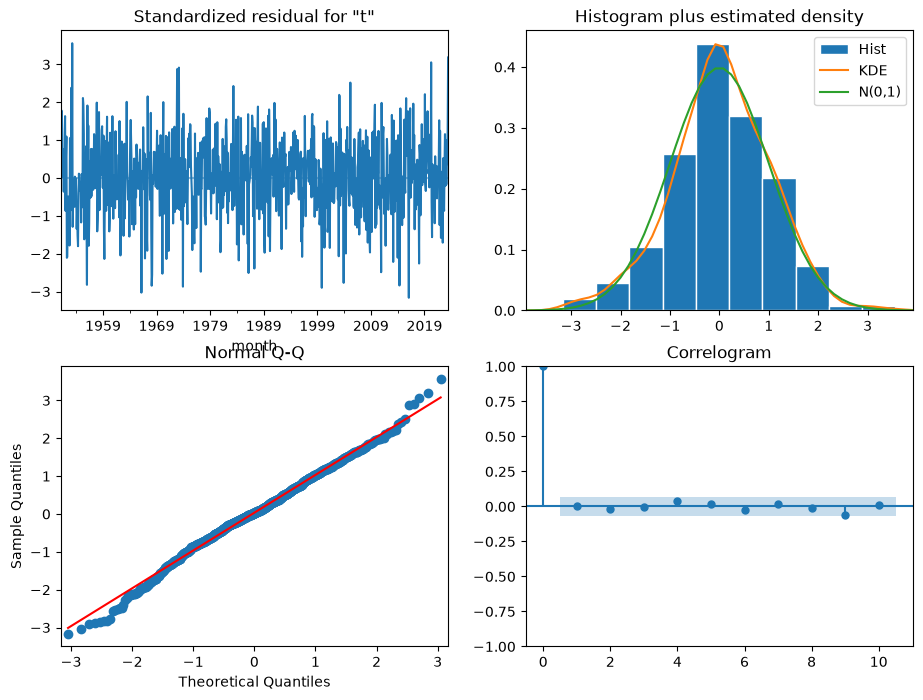

In [21]:
# b) diagnostico de residuos
modelo2.plot_diagnostics(figsize=(11, 8))
plt.show()

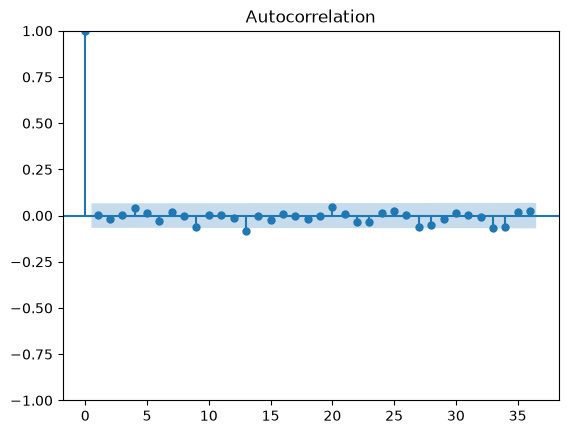

,lb_stat,lb_pvalue
12,6.963454,0.860019
24,18.819589,0.761541
36,34.341562,0.547584


In [22]:
from statsmodels.stats.diagnostic import acorr_ljungbox

resid = modelo2.resid[13:]  # se saltan los primeros valores afectados por la diferenciacion
plot_acf(resid, lags=36)
plt.show()
acorr_ljungbox(resid, lags=[12, 24, 36])

In [23]:
# c) comparacion con los modelos alternativos
for nombre, m in [("modelo1", modelo1), ("modelo2", modelo2), ("modelo3", modelo3)]:
    print(f"{nombre}: AIC={m.aic:.2f}  BIC={m.bic:.2f}")

modelo1: AIC=1465.98  BIC=1489.81
modelo2: AIC=1445.45  BIC=1478.82
modelo3: AIC=1451.58  BIC=1470.65


## Ejercicio 6

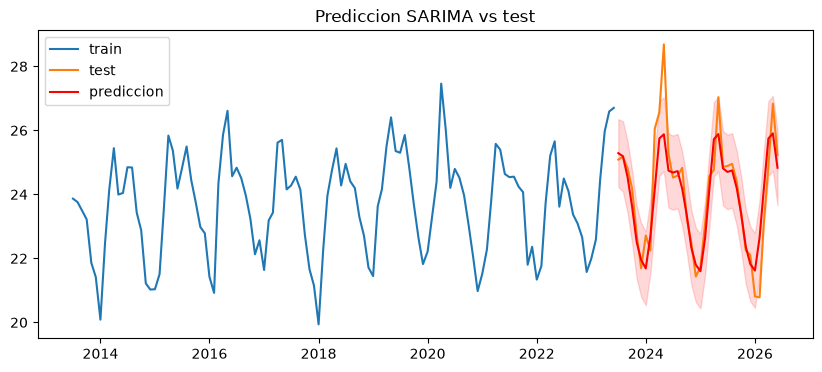

In [24]:
ts_test = test.set_index("month")["temperature_2m_c"]
ts_test.index.freq = "MS"

pred = modelo2.get_forecast(36)
pred_media = pred.predicted_mean
ci = pred.conf_int()

plt.figure(figsize=(10, 4))
plt.plot(ts[-120:], label="train")
plt.plot(ts_test, label="test")
plt.plot(pred_media, label="prediccion", color="red")
plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="red", alpha=0.15)
plt.legend()
plt.title("Prediccion SARIMA vs test")
plt.show()

In [25]:
rmse_sarima = np.sqrt(((ts_test - pred_media) ** 2).mean())
mae_sarima = (ts_test - pred_media).abs().mean()
print(f"RMSE: {rmse_sarima:.3f}  MAE: {mae_sarima:.3f}")

RMSE: 0.830  MAE: 0.576


## Ejercicio 7

In [26]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing

# holt winters con estacionalidad aditiva
hw = ExponentialSmoothing(ts, trend="add", seasonal="add", seasonal_periods=12).fit()
pred_hw = hw.forecast(36)

# suavizamiento exponencial simple (prediccion plana)
ses = SimpleExpSmoothing(ts).fit()
pred_ses = ses.forecast(36)

# seasonal naive: repetir los ultimos 12 meses del train
pred_snaive = pd.Series(np.tile(ts[-12:].values, 3), index=ts_test.index)

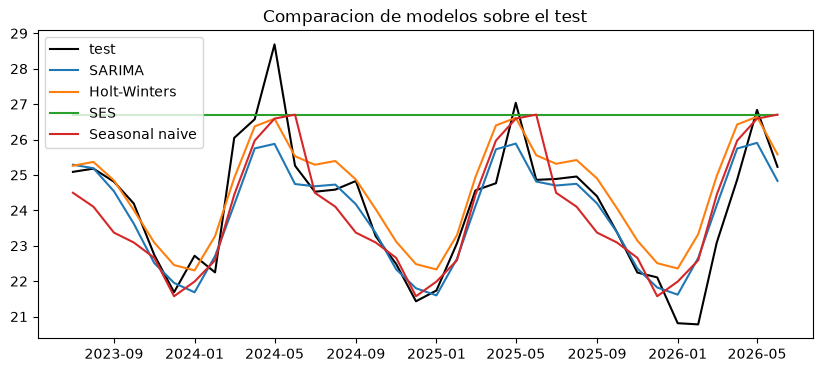

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(ts_test, label="test", color="black")
plt.plot(pred_media, label="SARIMA")
plt.plot(pred_hw, label="Holt-Winters")
plt.plot(pred_ses, label="SES")
plt.plot(pred_snaive, label="Seasonal naive")
plt.legend()
plt.title("Comparacion de modelos sobre el test")
plt.show()

In [28]:
def rmse(y, yhat):
    return np.sqrt(((y - yhat) ** 2).mean())

for nombre, p in [("SARIMA", pred_media), ("Holt-Winters", pred_hw), ("SES", pred_ses), ("Seasonal naive", pred_snaive)]:
    print(f"{nombre}: RMSE={rmse(ts_test, p):.3f}  MAE={(ts_test - p).abs().mean():.3f}")

SARIMA: RMSE=0.830  MAE=0.576
Holt-Winters: RMSE=0.944  MAE=0.730
SES: RMSE=3.205  MAE=2.784
Seasonal naive: RMSE=0.987  MAE=0.797


## Ejercicio 8

In [29]:
# comparar la prediccion contra los valores mas recientes (ultimos 12 meses del test)
comp = pd.DataFrame({"real": ts_test, "prediccion": pred_media})
comp["error"] = comp["real"] - comp["prediccion"]
comp["error_pct"] = (comp["error"].abs() / comp["real"]) * 100
comp.tail(12)

,real,prediccion,error,error_pct
2025-07-01,24.886029,24.701120,0.184908,0.743020
2025-08-01,24.955084,24.748899,0.206185,0.826225
2025-09-01,24.396005,24.195563,0.200442,0.821620
2025-10-01,23.384887,23.383602,0.001285,0.005495
2025-11-01,22.242929,22.356662,-0.113733,0.511323
2025-12-01,22.106394,21.821152,0.285242,1.290314
2026-01-01,20.812640,21.619364,-0.806725,3.876128
2026-02-01,20.779167,22.652770,-1.873603,9.016738
2026-03-01,23.084473,24.142299,-1.057826,4.582414
2026-04-01,24.868188,25.744606,-0.876418,3.524252


In [30]:
mape = comp["error_pct"].mean()
print(f"MAPE en los 36 meses: {mape:.2f}%")
print(f"MAPE en los ultimos 12 meses: {comp['error_pct'].tail(12).mean():.2f}%")
print(f"error maximo: {comp['error'].abs().max():.2f} C")

MAPE en los 36 meses: 2.36%
MAPE en los ultimos 12 meses: 2.52%
error maximo: 2.81 C
